In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

from algorithms.tss_file import TSSFile
from algorithms.wfm_edge import WFM_edge
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file = 'Tek20251202T082018.tss'
folder = r'Y:\TESTDATA\DP\2025\12\02\2545A001D3\Vd400_Id350_Vg15'
tss = TSSFile(folder, file, source='Local')
channel_labels = tss.channel_labels
print(channel_labels)
time = tss.waveforms['ch1'].time_for_frame()
vg = tss.waveforms['ch1'].values_for_frame(0)
vgi = tss.waveforms['ch2'].values_for_frame(0)
vd = tss.waveforms['ch3'].values_for_frame(0)
Is = tss.waveforms['ch4'].values_for_frame(0)
ig = tss.waveforms['ch5'].values_for_frame(0)
vblnk = tss.waveforms['ch6'].values_for_frame(0)
vcl = tss.waveforms['ch7'].values_for_frame(0)
flt = tss.waveforms['ch8'].values_for_frame(0)

{'ch1': 'Vg', 'ch2': 'Vgi', 'ch3': 'Vd', 'ch4': 'Is', 'ch5': 'MC_GATE', 'ch6': 'Vblnk', 'ch7': 'Vcl', 'ch8': 'Ig'}


[103979 165994 169299 171618]


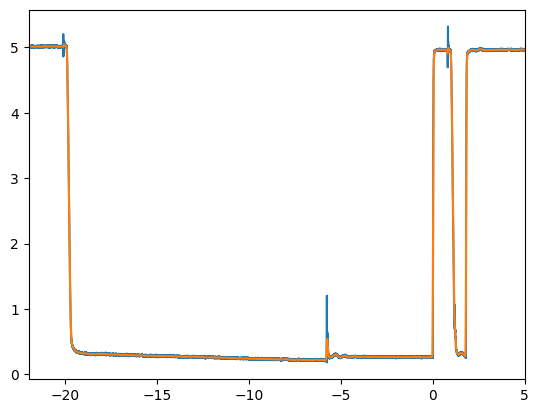

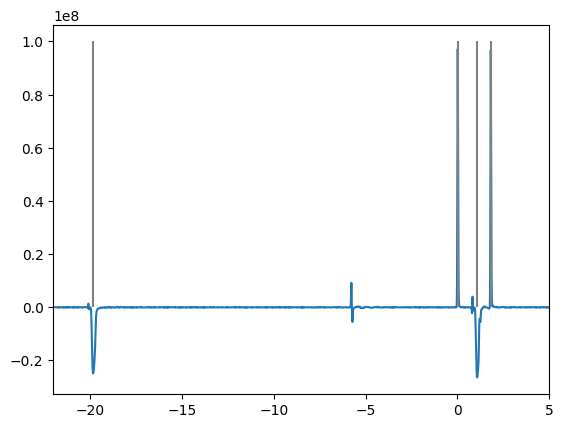

In [3]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


smoothed = gaussian_filter1d(vblnk, sigma=50)
derivative = np.gradient(smoothed, time)
prominence = np.abs(np.abs(derivative)).max() / 8
indices, props = find_peaks(np.abs(derivative), prominence=prominence, width=1, distance=1)
print(indices)
plt.plot(time*1e6, vblnk)
plt.plot(time*1e6, smoothed)
plt.xlim(-22, 5)
plt.show()

plt.plot(time*1e6, derivative)
plt.vlines(time[indices[0]]*1e6, 0, 1e8, color='grey')
plt.vlines(time[indices[1]]*1e6, 0, 1e8, color='grey')
plt.vlines(time[indices[2]]*1e6, 0, 1e8, color='grey')
plt.vlines(time[indices[3]]*1e6, 0, 1e8, color='grey')
plt.xlim(-22, 5)
plt.show()

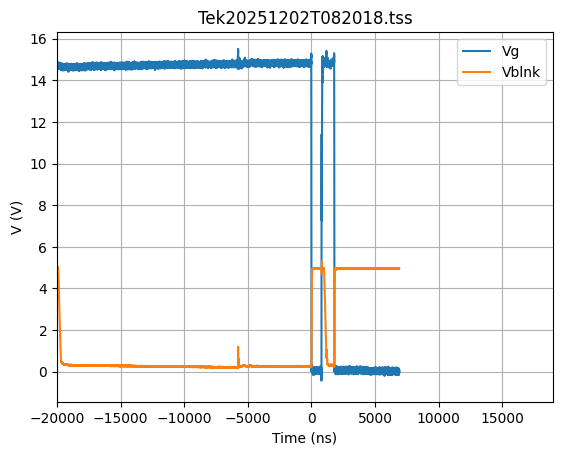

In [4]:
plt.plot(time*1e9, vg, label='Vg')
plt.plot(time*1e9, vblnk, label='Vblnk')
plt.xlim([-20000, 19000])
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()

2
2
-19881.79940645404
242.89783423102932


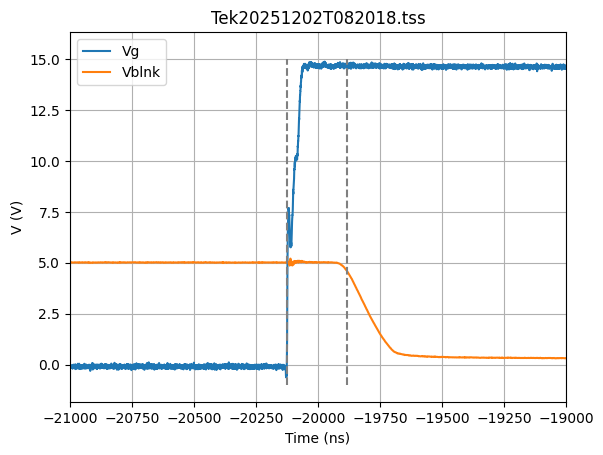

In [5]:
vg_edges = WFM_edge(vg, time)
vblnk_edges = WFM_edge(vblnk, time, sigma=50)
print(vblnk_edges.falling_edge_number)
print(vblnk_edges.rising_edge_number)
time1 = vg_edges.get_edge(1, 'rising', 10)['time']
time2 = vblnk_edges.get_edge(1, 'falling', 90)['time']
print(time2*1e9)
desat_blank = (time2 - time1) * 1e9
print(desat_blank)

plt.plot(time*1e9, vg, label='Vg')
plt.plot(time*1e9, vblnk, label='Vblnk')
plt.xlim([-21000, -19000])
plt.vlines(time1*1e9, -1, 15, color='grey', linestyles='--')
plt.vlines(time2*1e9, -1, 15, color='grey', linestyles='--')
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()

-193.8772568840297


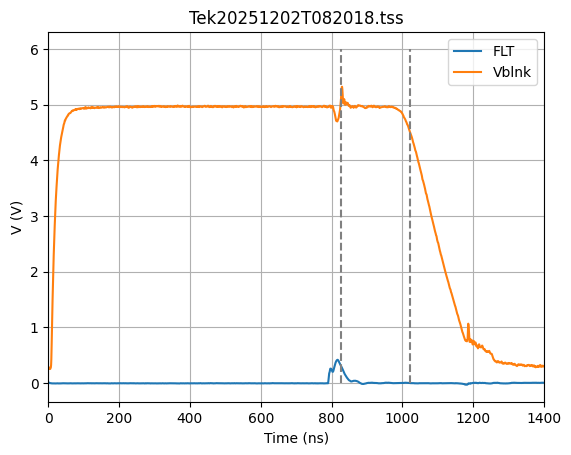

In [14]:
flt_edges = WFM_edge(flt, time)
time2 = vblnk_edges.get_edge(2, 'falling', 90)['time']
time3 = flt_edges.get_edge(2, 'falling', 90)['time']
desat_t_react  = (time3 - time2) * 1e9
print(desat_t_react)

plt.plot(time*1e9, flt, label='FLT')
plt.plot(time*1e9, vblnk, label='Vblnk')
plt.xlim([0, 1400])
#plt.xlim([-21000, 0])
plt.vlines(time2*1e9, 0, 6, color='grey', linestyles='--')
plt.vlines(time3*1e9, 0, 6, color='grey', linestyles='--')
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()

-20129.942637812852


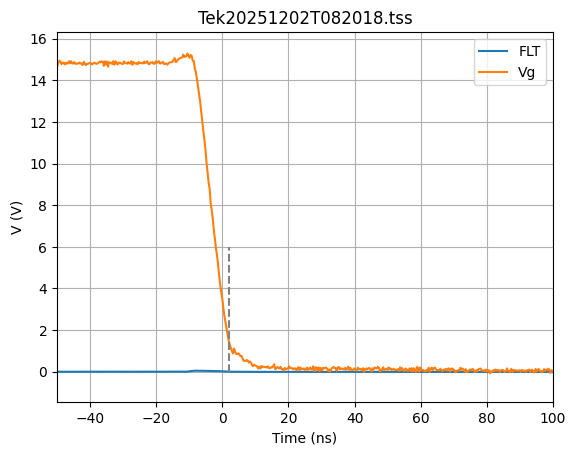

In [7]:
flt_edges = WFM_edge(flt, time)
time4 = vg_edges.get_edge(1, 'falling', 10)['time']
time5 = flt_edges.get_edge(1, 'rising', 10)['time']
desat_reset_time  = (time5 - time4) * 1e9
print(desat_reset_time)

plt.plot(time*1e9, flt, label='FLT')
plt.plot(time*1e9, vg, label='Vg')
plt.xlim([-50, 100])
#plt.xlim([-21000, 5400])
plt.vlines(time4*1e9, 0, 6, color='grey', linestyles='--')
plt.vlines(time5*1e9, 0, 6, color='grey', linestyles='--')
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()

In [8]:
vgi_edges = WFM_edge(vgi, time)
time6 = vgi_edges.get_edge(1, 'falling', 90)['time']
time7 = vgi_edges.get_edge(1, 'falling', 10)['time']
desat_VGI_tlow  = (time7 - time6) * 1e9
print(desat_VGI_tlow)

66.40016821090325


In [9]:
idx1 = vgi_edges.get_edge(1, 'falling', 99)['thresh_idx']
idx2 = vgi_edges.get_edge(1, 'falling', 1)['thresh_idx']
is_max = max(Is[(idx1-(idx2-idx1)):(idx2+(idx2-idx1))])
print(is_max)

240.31249999999994



-23.749999999999716
0.956535000000076


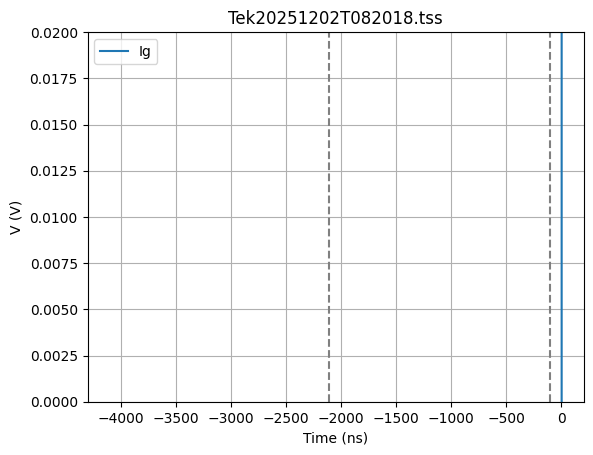

In [10]:
time_inter = time[1] - time[0]
idx4 = vg_edges.get_edge(1, 'falling', 99)['thresh_idx'] - int(0.1e-6/time_inter)
idx3 = np.argmin(np.abs(time - (time[idx4]-2e-6)))

print()
desat_Ig_max = max(ig[idx3:idx4])*1e3
print(desat_Ig_max)
desat_flt_Vactive = np.average(flt[idx3:idx4])*1e3
print(desat_flt_Vactive)

plt.plot(time*1e9, ig, label='Ig')
plt.xlim([-4300, 200])
plt.ylim([0,0.02])
#plt.xlim([-21000, 5400])
plt.vlines(time[idx3]*1e9, 0, 0.1, color='grey', linestyles='--')
plt.vlines(time[idx4]*1e9, 0, 0.1, color='grey', linestyles='--')
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()

0.3974479166666665


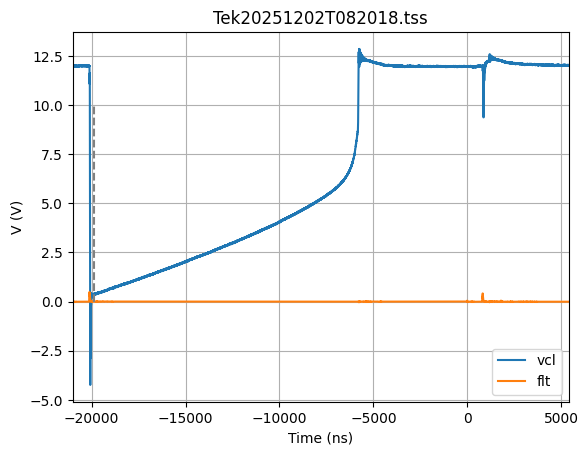

In [11]:
time8 = flt_edges.get_edge(1, 'falling', 10)['time'] - desat_t_react*1e-9
idx5 = np.argmin(np.abs(time - time8))
desat_VDS_th = np.average(vcl[idx5-3:idx5+3])
print(desat_VDS_th)

plt.plot(time*1e9, vcl, label='vcl')
plt.plot(time*1e9, flt, label='flt')
#plt.xlim([-4300, 200])
plt.xlim([-21000, 5400])
plt.vlines(time[idx5]*1e9, 0, 10, color='grey', linestyles='--')
plt.xlabel('Time (ns)')
plt.ylabel('V (V)')
plt.title(f'{file}')
plt.legend()
plt.grid()
plt.show()